### 1 Подготовительный этап
Выполнил: Татьяна Шувайникова 

In [235]:
import pandas as pd
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

*   Cчитывание набора данных из файла формата .csv в DataFrame
*   Удаление дубликатов

In [236]:
df = pd.read_csv('dataset_2025-03-01_2026-03-29_external.csv')
data = df.drop_duplicates(subset=None, keep='first', inplace=False)
df

,lead_id,sale_ts,sale_date,buyout_flag,outcome_unknown,handed_to_delivery_ts,issued_or_pvz_ts,received_ts,rejected_ts,returned_ts,...,lead_RS_STAT,lead_Номер линии билайн:,lead_ETEXT,lead_Ответственный за доставку,lead_AI_abcde,lead_YSCLID,contact_Max ID,lead_POLICY_MARKETING,lead_ASSET-CLICK,lead_URL
0,LEAD_0172,1740807306,2025-03-01,True,False,1.741339e+09,1.741782e+09,1.741782e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,LEAD_0176,1740808264,2025-03-01,True,False,1.741339e+09,1.741609e+09,1.741620e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,LEAD_0177,1740808445,2025-03-01,True,False,1.741254e+09,1.742355e+09,1.742366e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LEAD_0182,1740809886,2025-03-01,True,False,1.741170e+09,1.741516e+09,1.741620e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,LEAD_0180,1740811327,2025-03-01,True,False,1.741253e+09,1.741503e+09,1.741516e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18882,LEAD_18780,1774800364,2026-03-29,NaN,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://artraid-dem.ru/otek_clip4
18883,LEAD_18885,1774800486,2026-03-29,NaN,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://artraid-dem.ru/sleep-clip3
18884,LEAD_15144,1774801205,2026-03-29,NaN,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18885,LEAD_18887,1774802524,2026-03-29,NaN,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,ETX_0059,NaN,NaN,NaN,NaN,NaN,NaN,https://artraide.pro/varikoz_clip4


In [237]:
data

,lead_id,sale_ts,sale_date,buyout_flag,outcome_unknown,handed_to_delivery_ts,issued_or_pvz_ts,received_ts,rejected_ts,returned_ts,...,lead_RS_STAT,lead_Номер линии билайн:,lead_ETEXT,lead_Ответственный за доставку,lead_AI_abcde,lead_YSCLID,contact_Max ID,lead_POLICY_MARKETING,lead_ASSET-CLICK,lead_URL
0,LEAD_0172,1740807306,2025-03-01,True,False,1.741339e+09,1.741782e+09,1.741782e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,LEAD_0176,1740808264,2025-03-01,True,False,1.741339e+09,1.741609e+09,1.741620e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,LEAD_0177,1740808445,2025-03-01,True,False,1.741254e+09,1.742355e+09,1.742366e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LEAD_0182,1740809886,2025-03-01,True,False,1.741170e+09,1.741516e+09,1.741620e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,LEAD_0180,1740811327,2025-03-01,True,False,1.741253e+09,1.741503e+09,1.741516e+09,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18882,LEAD_18780,1774800364,2026-03-29,NaN,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://artraid-dem.ru/otek_clip4
18883,LEAD_18885,1774800486,2026-03-29,NaN,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,https://artraid-dem.ru/sleep-clip3
18884,LEAD_15144,1774801205,2026-03-29,NaN,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18885,LEAD_18887,1774802524,2026-03-29,NaN,True,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,ETX_0059,NaN,NaN,NaN,NaN,NaN,NaN,https://artraide.pro/varikoz_clip4


Вывод 1: Дубликатов напрямую не выявленно

---


 Первичная замена категориальных параметров на числовые


In [238]:
for col in df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

for col in df.select_dtypes(include=['bool']).columns:
    df[col] = df[col].astype(int)

corr_matrix = df.corr()

df

,lead_id,sale_ts,sale_date,buyout_flag,outcome_unknown,handed_to_delivery_ts,issued_or_pvz_ts,received_ts,rejected_ts,returned_ts,...,lead_RS_STAT,lead_Номер линии билайн:,lead_ETEXT,lead_Ответственный за доставку,lead_AI_abcde,lead_YSCLID,contact_Max ID,lead_POLICY_MARKETING,lead_ASSET-CLICK,lead_URL
0,171,1740807306,0,1,0,1.741339e+09,1.741782e+09,1.741782e+09,NaN,NaN,...,1,1,143,2,1,10,2,1,1,23
1,175,1740808264,0,1,0,1.741339e+09,1.741609e+09,1.741620e+09,NaN,NaN,...,1,1,143,2,1,10,2,1,1,23
2,176,1740808445,0,1,0,1.741254e+09,1.742355e+09,1.742366e+09,NaN,NaN,...,1,1,143,2,1,10,2,1,1,23
3,181,1740809886,0,1,0,1.741170e+09,1.741516e+09,1.741620e+09,NaN,NaN,...,1,1,143,2,1,10,2,1,1,23
4,179,1740811327,0,1,0,1.741253e+09,1.741503e+09,1.741516e+09,NaN,NaN,...,1,1,143,2,1,10,2,1,1,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18882,10658,1774800364,393,2,1,NaN,NaN,NaN,NaN,NaN,...,1,1,143,2,1,10,2,1,1,1
18883,10773,1774800486,393,2,1,NaN,NaN,NaN,NaN,NaN,...,1,1,143,2,1,10,2,1,1,2
18884,6658,1774801205,393,2,1,NaN,NaN,NaN,NaN,NaN,...,1,1,143,2,1,10,2,1,1,23
18885,10775,1774802524,393,2,1,NaN,NaN,NaN,NaN,NaN,...,1,1,58,2,1,10,2,1,1,20


In [ ]:
plt.figure(figsize=(50, 50))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Взаимная корреляционная матрица признаков")
plt.show()

Вывод 2: Выявлены следующие особенности:
1) Необходимо определить состав товара как столбец с кол-вом позиций + столбец с набором артикулов
2) Необходимо определить все признаки адресов (покупателя и ПВЗ) как город, считываемый из соответствующих заполненных ячеек с полными адресами в разных форматах


Вывод 3: По матрице корреляции видно, что имеются признаки, имеющие значение близкое к -1 или 1, соответственно между ними есть определенная зависимость. Можно оставить лишь один из пар взаимнокоррелирующих признаков.

---

Сохранение получившегося датасета с числовыми значениями в файл output_1.csv для проведения детального анализа в LibreOffice Calc по каждому столбцу признаков:

*   Анализ диапазона значений
*   Расшифровка категориальных признаков, переведенных в числовой формат (Расшифровка Dataset.docx)
*   Выявление столбцов, характеризующих один и тот же признак
*   Выявление столбцов с уникальными значениями в строках
*   Выявление столбцов имеющих малую информативность для сбора статистики (только 1-2 строки с заполненным значением)
*   Выявление столбцов с избыточной информацией


In [201]:
df.to_csv("output_1.csv", index=False)

In [202]:
deleted_list = ['lead_group_id', 'lead_status_id', 'lead_loss_reason_id', 'lead_is_deleted', 'lead_Дата создания сделки',
                'lead_будущие покупки', 'lead_Компания Отправитель', 'lead_Дата получения денег на Р/С', 'contact_id',
                'contact_created_at', 'contact_updated_at', 'contact_Код ПВЗ', 'lead_utm_source', 'lead_utm_medium', 'lead_utm_campaign',
                'lead_utm_content', 'lead_utm_term', 'lead_utm_group', 'lead_utm_sky', 'lead_FORMNAME', 'lead_utm_referrer', 'lead_source',
                'lead_Почтовый индекс', 'lead_Статус заказа на сайте', 'lead_Тип отправления', 'lead_Счет оплачен',
                'lead_Дата перехода Передан в доставку', 'lead_Ответственный за доставку', 'lead_Нумерация сделки',
                'lead_Дата приобретения изделия', 'lead_Поиск товаров GoSklad', 'lead_ACTUAL-FORMAT', 'lead_BANNER-SIZES', 'lead_WIDTH',
                'lead_HEIGHT', 'lead_Список товаров GoSklad', 'lead_name', 'lead_REFERER', 'lifecycle_incomplete', 'current_status_id', 'lead_tags',
               'lead_account_id', 'lead_COOKIES', 'lead_Оплата МОП', 'contact_name', 'contact_first_name', 'contact_Телефон', 'contact_Адрес клиента',
               'contact_Комментарии', 'lead_Комментарий к заказу', 'lead_Адрес подробно', 'lead_Ссылка на бланк отправления', 'lead_Оплата за лид',
                'contact_Email', 'contact_День рождения', 'contact_Звонок Директ Callibri', 'lead_ФИО', 'lead_Адрес доставки', 'lead_Полный адрес',
               'lead_CHECKBOX', 'lead_Индекс отделения отправки', 'contact_Source phone', 'lead_TILDASPEC-ELEMID', 'lead_Объявление', 'lead_URL объявления',
               'contact_Whatsgroup_WZ', 'contact_Канал Callibri', 'lead_Ссылка на документ', 'lead_Выбранные товары', 'contact_Ссылка на документ',
               'lead_Solo', 'lead_YBAIP', 'lead_from', 'lead_Source phone', 'lead_ИМ сдэк', 'lead_Комментарий к отправлению', 'lead_POLICY', 'lead_TEST-TAG',
               'lead_CTIME', 'lead_PCODEVER', 'lead_BANNER-TEST-TAGS', 'lead_BANNERS-VIDEOS', 'lead_CONSTRUCTOR-RENDERED-ASSETS', 'lead_RENDERED-DIRECT-ASSETS',
               'lead_STAT-ID', 'lead_PCODE-ACTIVE-TESTIDS', 'lead_ORDER-BANNERS-OPTIONS', 'lead_CLICK-TIME', 'lead_CLICKX', 'lead_CLICKY', 'lead_CB', 'lead_RS_STAT',
               'lead_Номер линии билайн:', 'lead_AI_abcde', 'contact_Max ID', 'lead_POLICY_MARKETING', 'lead_ASSET-CLICK', 'lead_URL']
df = df.drop(deleted_list, axis=1)

Сохранение файла output_2.csv нового датасета без избыточных столбцов (в числовом формате для последующей обработки)

In [203]:
df.to_csv("output_2.csv", index=False)

Сохранение файла data_2.csv нового датасета без избыточных столбцов (в начальном виде для проведения последующего анализа и расшифровки)

In [204]:
data = pd.read_csv('dataset_2025-03-01_2026-03-29_external.csv')
data = data.drop(deleted_list, axis=1)
data.to_csv("data_2.csv", index=False)

Построение матрицы взаимной корреляции оставшихся признаков нового датасета (после удаления избыточных столбцов)

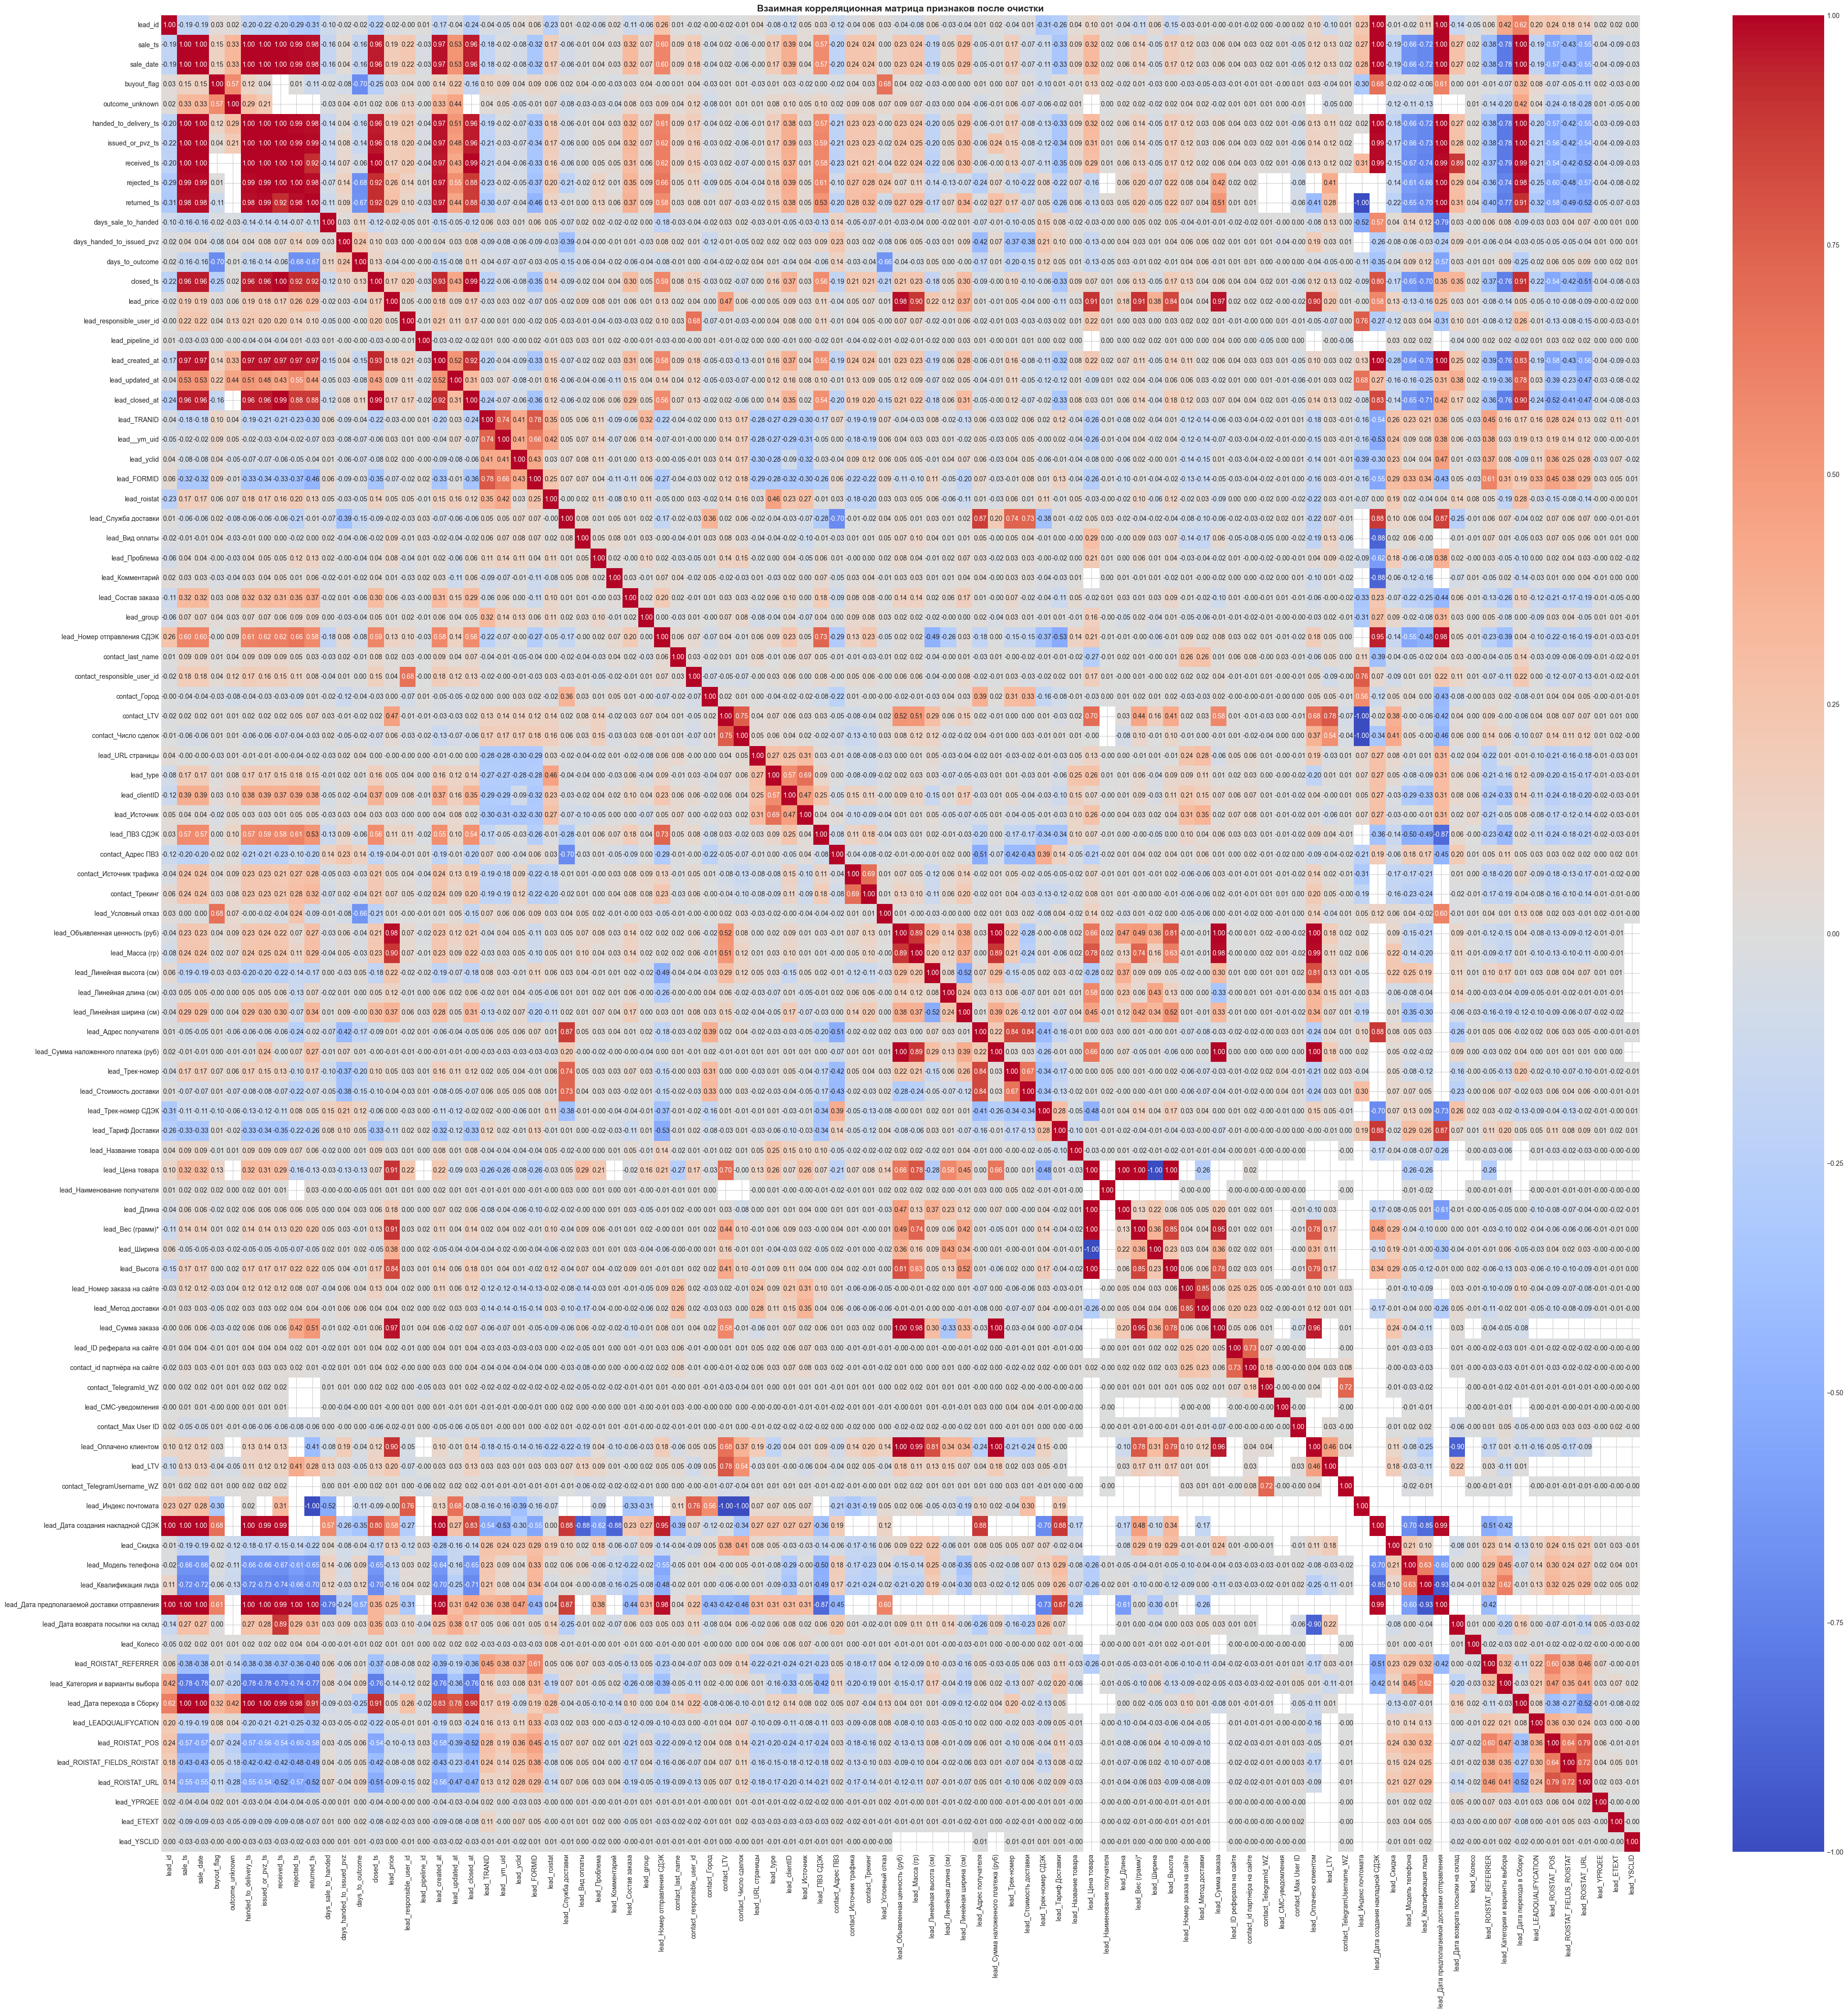

In [205]:
corr_matrix = df.corr()
plt.figure(figsize=(50, 50))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Взаимная корреляционная матрица признаков после очистки")
plt.show()

In [206]:
df

,lead_id,sale_ts,sale_date,buyout_flag,outcome_unknown,handed_to_delivery_ts,issued_or_pvz_ts,received_ts,rejected_ts,returned_ts,...,lead_ROISTAT_REFERRER,lead_Категория и варианты выбора,lead_Дата перехода в Сборку,lead_LEADQUALIFYCATION,lead_ROISTAT_POS,lead_ROISTAT_FIELDS_ROISTAT,lead_ROISTAT_URL,lead_YPRQEE,lead_ETEXT,lead_YSCLID
0,171,1740807306,0,1,0,1.741339e+09,1.741782e+09,1.741782e+09,NaN,NaN,...,841,5,NaN,1,7,3380,32,30,143,10
1,175,1740808264,0,1,0,1.741339e+09,1.741609e+09,1.741620e+09,NaN,NaN,...,841,5,NaN,1,7,3380,32,30,143,10
2,176,1740808445,0,1,0,1.741254e+09,1.742355e+09,1.742366e+09,NaN,NaN,...,841,5,NaN,1,7,3380,32,30,143,10
3,181,1740809886,0,1,0,1.741170e+09,1.741516e+09,1.741620e+09,NaN,NaN,...,841,5,NaN,1,7,3380,32,30,143,10
4,179,1740811327,0,1,0,1.741253e+09,1.741503e+09,1.741516e+09,NaN,NaN,...,841,5,NaN,1,7,3380,32,30,143,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18882,10658,1774800364,393,2,1,NaN,NaN,NaN,NaN,NaN,...,544,1,1.774732e+09,1,1,160,4,30,143,10
18883,10773,1774800486,393,2,1,NaN,NaN,NaN,NaN,NaN,...,311,2,1.774732e+09,1,1,226,5,30,143,10
18884,6658,1774801205,393,2,1,NaN,NaN,NaN,NaN,NaN,...,229,3,1.774732e+09,0,1,1377,4,30,143,10
18885,10775,1774802524,393,2,1,NaN,NaN,NaN,NaN,NaN,...,841,3,1.774732e+09,1,7,3380,28,30,58,10


Вывод 4: Количество признаков снижено с 191 до 93. \
Вывод 5: В матрице взаимной корреляции оставшиеся коррелируемые признаки - это метки времени, необходимые для дальнейших расчетов и анализа. В остальном прямая зависимость признаков друг с другом уменьшена.

### 2 Когортный анализ
Выполнил: Матвей Сабиров 

In [207]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Настройка строгого стиля графиков
plt.style.use('seaborn-v0_8-whitegrid')

# Словарь для перевода месяцев
MONTHS_RU = {
    'January': 'Январь', 'February': 'Февраль', 'March': 'Март',
    'April': 'Апрель', 'May': 'Май', 'June': 'Июнь',
    'July': 'Июль', 'August': 'Август', 'September': 'Сентябрь',
    'October': 'Октябрь', 'November': 'Ноябрь', 'December': 'Декабрь'
}

In [208]:
# 1. Чтение данных
df = pd.read_csv('output_2.csv', low_memory=False)
print("Предобработка данных для когортного анализа")

df_clean = df.copy()

# 2. Формирование когорт (по надежному sale_ts)
if 'sale_ts' in df_clean.columns:
    df_clean['sale_ts_dt'] = pd.to_datetime(df_clean['sale_ts'], unit='s')
    df_clean['sale_year'] = df_clean['sale_ts_dt'].dt.year
    df_clean['sale_month_num'] = df_clean['sale_ts_dt'].dt.month
    
    # Ключ для хронологической сортировки
    df_clean['month_sort_key'] = df_clean['sale_year'] * 12 + df_clean['sale_month_num']
    
    # Названия когорт
    df_clean['month_name_ru'] = df_clean['sale_ts_dt'].dt.month_name().map(MONTHS_RU)
    df_clean['cohort_name'] = df_clean['month_name_ru'] + ' ' + df_clean['sale_year'].astype(str)
else:
    print("Ошибка: отсутствует столбец sale_ts")

# 3. Базовая очистка
df_clean = df_clean.dropna(subset=['buyout_flag']).copy()

# Расчет дней до исхода (если столбца нет, вычисляем его)
if 'days_to_outcome' not in df_clean.columns:
    if 'closed_ts' in df_clean.columns and 'sale_ts' in df_clean.columns:
        df_clean['days_to_outcome'] = (df_clean['closed_ts'] - df_clean['sale_ts']) / 86400

df_clean['days_to_outcome'] = pd.to_numeric(df_clean['days_to_outcome'], errors='coerce')
df_clean = df_clean[df_clean['days_to_outcome'].notna()]

# Приводим флаг к логическому типу
if df_clean['buyout_flag'].dtype == 'object':
    df_clean['buyout_flag'] = df_clean['buyout_flag'].map({'True': True, 'False': False, '1': True, '0': False})
df_clean['buyout_flag'] = df_clean['buyout_flag'].astype(bool)

# Ограничиваем дни (основной выкуп происходит в первые 20 дней)
MAX_DAYS = 20
df_clean = df_clean[df_clean['days_to_outcome'] <= MAX_DAYS].copy()
df_clean['days_to_outcome_int'] = df_clean['days_to_outcome'].astype(int)

# Список уникальных когорт в хронологическом порядке
months_data = df_clean[['cohort_name', 'month_sort_key']].drop_duplicates().dropna()
months_data = months_data.sort_values('month_sort_key')
cohorts_list = months_data['cohort_name'].tolist()

print(f"Осталось после очистки: {len(df_clean):,.0f} заказов.")
print(f"Когорты в выборке: {', '.join(cohorts_list)}")

Предобработка данных для когортного анализа
Осталось после очистки: 14,504 заказов.
Когорты в выборке: Март 2025, Апрель 2025, Май 2025, Июнь 2025, Июль 2025, Август 2025, Сентябрь 2025, Октябрь 2025, Ноябрь 2025, Декабрь 2025, Январь 2026, Февраль 2026, Март 2026


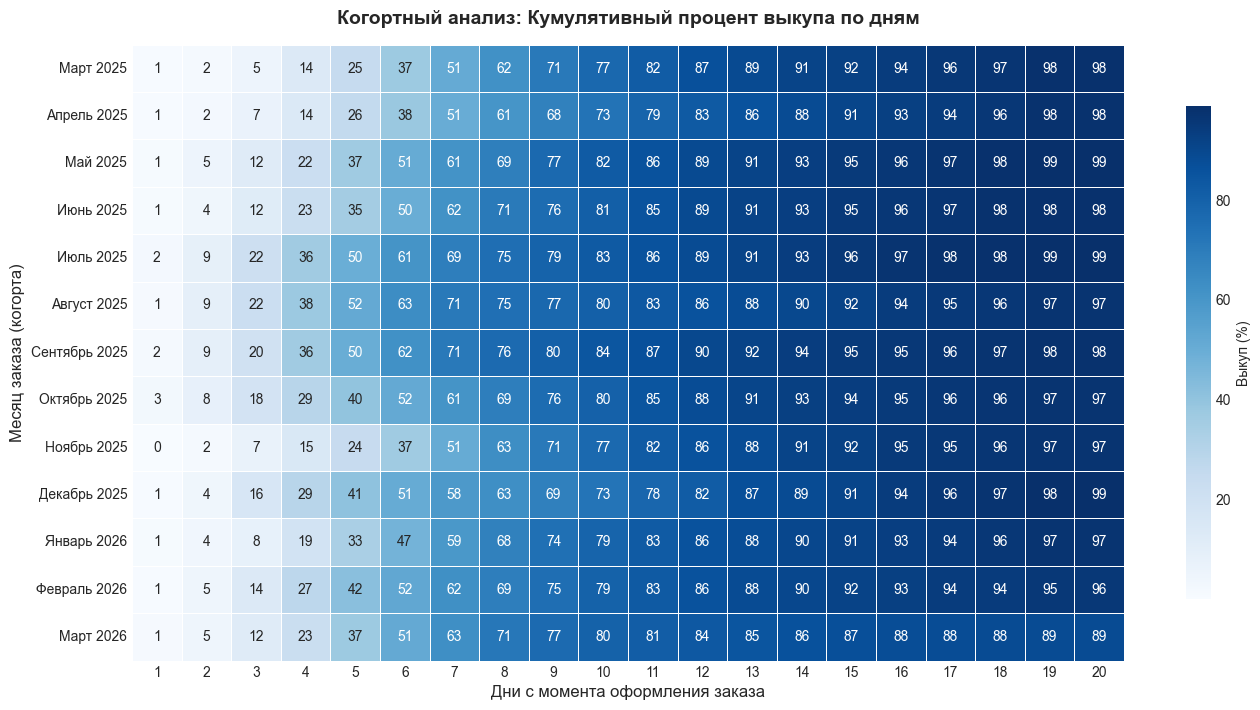

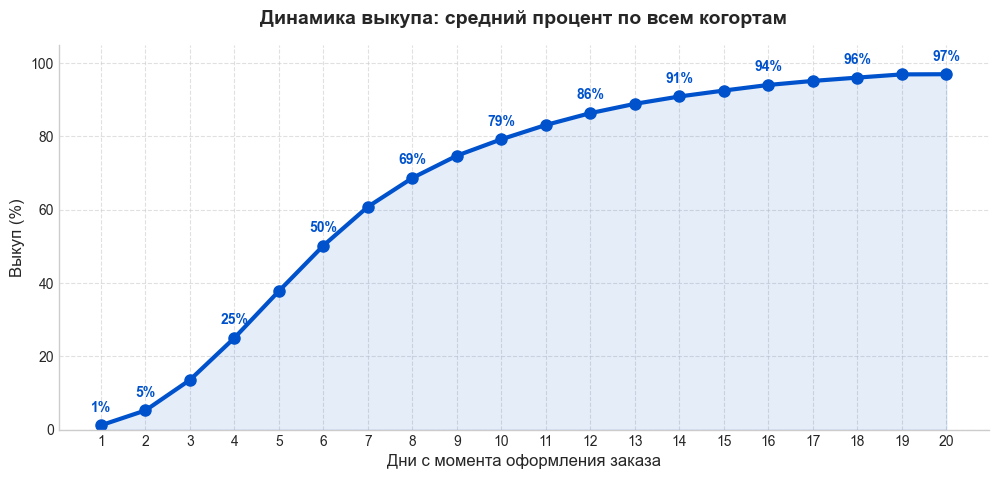

Вывод: К 20-му дню в среднем выкупается 96.9% заказов.
Основная доля выкупов приходится на первые 10-14 дней.


In [209]:
# Формирование матрицы когорт
cohort_matrix = pd.DataFrame(index=cohorts_list, columns=range(1, MAX_DAYS + 1))

for month in cohorts_list:
    group = df_clean[df_clean['cohort_name'] == month]
    total_orders = len(group)
    if total_orders == 0: continue

    for day in range(1, MAX_DAYS + 1):
        buyouts_up_to_day = group[(group['buyout_flag'] == True) & 
                                  (group['days_to_outcome_int'] <= day)].shape[0]
        cohort_matrix.loc[month, day] = (buyouts_up_to_day / total_orders) * 100

cohort_matrix = cohort_matrix.fillna(0).astype(float)

# 1. Построение тепловой карты
plt.figure(figsize=(16, 8))
sns.heatmap(
    cohort_matrix, 
    cmap='Blues', 
    annot=True, 
    fmt='.0f',
    cbar_kws={'label': 'Выкуп (%)', 'shrink': 0.8},
    linewidths=0.5, 
    linecolor='white'
)
plt.title('Когортный анализ: Кумулятивный процент выкупа по дням', fontsize=14, pad=15)
plt.xlabel('Дни с момента оформления заказа', fontsize=12)
plt.ylabel('Месяц заказа (когорта)', fontsize=12)
plt.show()

# 2. Построение усредненной кривой
avg_buyout = cohort_matrix.mean(axis=0)

plt.figure(figsize=(12, 5))
plt.plot(avg_buyout.index, avg_buyout.values, marker='o', linewidth=3, markersize=8, color='#0052cc')
plt.fill_between(avg_buyout.index, avg_buyout.values, alpha=0.1, color='#0052cc')

plt.title('Динамика выкупа: средний процент по всем когортам', fontsize=14, pad=15)
plt.xlabel('Дни с момента оформления заказа', fontsize=12)
plt.ylabel('Выкуп (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(range(1, MAX_DAYS + 1))
plt.ylim(0, 105)

# Чистка визуала
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Точечные подписи
for day, val in avg_buyout.items():
    if day % 2 == 0 or day == 1 or day == MAX_DAYS:
        plt.annotate(f'{val:.0f}%', (day, val), textcoords="offset points", 
                     xytext=(0, 10), ha='center', fontsize=10, color='#0052cc', fontweight='bold')

plt.show()

print(f"Вывод: К {MAX_DAYS}-му дню в среднем выкупается {avg_buyout[MAX_DAYS]:.1f}% заказов.")
print("Основная доля выкупов приходится на первые 10-14 дней.")

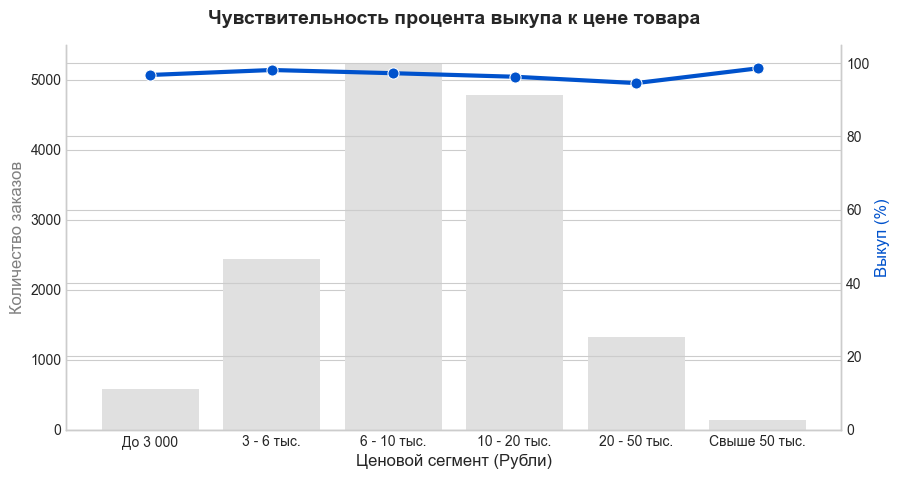

  Сводка по ценовым сегментам  


,Заказов,Выкуп_Процент
price_segment,,
До 3 000,577,96.7%
3 - 6 тыс.,"2,432",98.1%
6 - 10 тыс.,"5,238",97.2%
10 - 20 тыс.,"4,775",96.2%
20 - 50 тыс.,"1,327",94.5%
Свыше 50 тыс.,135,98.5%


In [210]:
if 'lead_price' in df_clean.columns:
    df_clean['lead_price'] = pd.to_numeric(df_clean['lead_price'], errors='coerce')
    price_data = df_clean[df_clean['lead_price'] <= 100000].copy() # Отсекаем выбросы

    price_bins = [0, 3000, 6000, 10000, 20000, 50000, 100000]
    price_labels = ['До 3 000', '3 - 6 тыс.', '6 - 10 тыс.', '10 - 20 тыс.', '20 - 50 тыс.', 'Свыше 50 тыс.']
    
    price_data['price_segment'] = pd.cut(price_data['lead_price'], bins=price_bins, labels=price_labels, right=False)

    segment_stats = price_data.groupby('price_segment', observed=False).agg(
        Заказов=('buyout_flag', 'count'),
        Выкуп_Процент=('buyout_flag', lambda x: x.mean() * 100)
    ).dropna()

    fig, ax1 = plt.subplots(figsize=(10, 5))

    # Объем заказов (серые столбцы)
    sns.barplot(x=segment_stats.index, y='Заказов', data=segment_stats, color='#e0e0e0', ax=ax1)
    ax1.set_ylabel('Количество заказов', color='gray', fontsize=12)
    ax1.set_xlabel('Ценовой сегмент (Рубли)', fontsize=12)
    
    # Выкуп (синяя линия)
    ax2 = ax1.twinx()
    sns.lineplot(x=range(len(segment_stats)), y='Выкуп_Процент', data=segment_stats, 
                 color='#0052cc', marker='o', linewidth=3, markersize=8, ax=ax2)
    ax2.set_ylabel('Выкуп (%)', color='#0052cc', fontsize=12)
    ax2.set_ylim(0, 105)

    plt.title('Чувствительность процента выкупа к цене товара', fontsize=14, pad=15)
    ax1.spines['top'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    plt.show()
    
    print("  Сводка по ценовым сегментам  ")
    formatted_stats = segment_stats.copy()
    formatted_stats['Выкуп_Процент'] = formatted_stats['Выкуп_Процент'].apply(lambda x: f"{x:.1f}%")
    formatted_stats['Заказов'] = formatted_stats['Заказов'].apply(lambda x: f"{x:,.0f}")
    display(formatted_stats)

In [211]:
def print_category_stats(df, column, title, top_n=5, min_orders=30):
    if column not in df.columns:
        return
        
    df[column] = df[column].fillna('unknown').astype(str)
    
    stats = df.groupby(column).agg(
        orders=('buyout_flag', 'count'),
        buyout_rate=('buyout_flag', 'mean')
    ).reset_index()
    
    stats['buyout_rate'] *= 100
    stats['lost_orders'] = stats['orders'] * (100 - stats['buyout_rate']) / 100
    
    # Сортировка по упущенным заказам (ищем слабые места)
    stats = stats[stats['orders'] >= min_orders].sort_values('lost_orders', ascending=False)
    
    print(f"  ТОП-{top_n} проблемных зон: {title} (От {min_orders} заказов)  ")
    
    display_df = stats.head(top_n).copy()
    display_df.rename(columns={
        column: 'Категория',
        'orders': 'Всего_заказов',
        'buyout_rate': 'Выкуп_%',
        'lost_orders': 'Потеряно_заказов_шт'
    }, inplace=True)
    
    display_df['Выкуп_%'] = display_df['Выкуп_%'].apply(lambda x: f"{x:.1f}%")
    display_df['Потеряно_заказов_шт'] = display_df['Потеряно_заказов_шт'].apply(lambda x: f"{x:,.0f}")
    
    display(display_df.reset_index(drop=True))
    print("\n")

# Запуск анализа
print_category_stats(df_clean, 'contact_Город', 'Города и Регионы', min_orders=20)
print_category_stats(df_clean, 'contact_responsible_user_id', 'Менеджеры (ID)', min_orders=30)
print_category_stats(df_clean, 'lead_Служба доставки', 'Службы доставки', min_orders=10)
print_category_stats(df_clean, 'lead_Вид оплаты', 'Виды оплаты', min_orders=10)



  ТОП-5 проблемных зон: Города и Регионы (От 20 заказов)  


,Категория,Всего_заказов,Выкуп_%,Потеряно_заказов_шт
0,3501,1859,96.5%,65
1,4320,613,97.7%,14
2,3085,154,94.2%,9
3,2563,184,95.7%,8
4,3772,207,96.1%,8




  ТОП-5 проблемных зон: Менеджеры (ID) (От 30 заказов)  


,Категория,Всего_заказов,Выкуп_%,Потеряно_заказов_шт
0,1,3182,98.1%,62
1,0,2279,97.7%,53
2,5,1336,96.3%,50
3,29,1972,97.7%,45
4,6,707,95.9%,29




  ТОП-5 проблемных зон: Службы доставки (От 10 заказов)  


,Категория,Всего_заказов,Выкуп_%,Потеряно_заказов_шт
0,3,10625,97.3%,292
1,2,2018,94.7%,106
2,1,1834,96.6%,63
3,4,19,94.7%,1




  ТОП-5 проблемных зон: Виды оплаты (От 10 заказов)  


,Категория,Всего_заказов,Выкуп_%,Потеряно_заказов_шт
0,0,13768,96.7%,457
1,4,10,40.0%,6
2,3,564,99.1%,5
3,2,159,100.0%,0


### 3-4 Прогнозирование выкупа
Выполнил: Елена Монсевич

In [212]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from catboost import CatBoostClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, precision_recall_curve, average_precision_score)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

##### Предобработка данных

In [213]:
# 1. Чтение данных
df = pd.read_csv('output_2.csv', low_memory=False)

In [214]:
# 2. Предобработка данных
target_col = 'buyout_flag'
cols_to_drop = [
    # Временные утечки (события после создания сделки)
    'received_ts', 'rejected_ts', 'returned_ts', 'closed_ts', 
    'issued_or_pvz_ts', 'handed_to_delivery_ts', 'lead_closed_at', 
    'lead_updated_at', 'lead_Дата возврата посылки на склад',
    'lead_Дата перехода Передан в доставку', 'days_to_outcome',
    'days_handed_to_issued_pvz', 'lead_Дата перехода в Сборку',	
    # Идентификаторы и утечки статусов
    'lead_id', 'lead_id_1', 'lead_status_id', 'lead_pipeline_id',
    'lead_Трек-номер', 'lead_Трек-номер СДЭК', 'lead_Номер отправления СДЭК',
    'lead_Условный отказ', 'contact_id', 'outcome_unknown', 'lead__ym_uid',
    # Хотя организатор заявляет, что в пожизненную ценность не попадают будущие периоды, но значимость признака ~60% и высокие метрики точнсости
    # говорят об обратном. Поэтому мы убиарем этот признак, как зависимый от выкупа.
    'contact_LTV'
]

# Отфильтровываем значения 2, оставляя только 0 и 1
df_cleaned = df[df[target_col].isin([0, 1])].copy()

# Удаляем указанные столбцы 
df_cleaned = df_cleaned.drop(columns=cols_to_drop, errors='ignore')

# Обработка состава заказа как категориального признака
if 'lead_Состав заказа' in df_cleaned.columns:
    # Заполняем пропуски словом 'unknown' и переводим все коды в строки
    df_cleaned['lead_Состав заказа'] = df_cleaned['lead_Состав заказа'].fillna('unknown').astype(str)
    
# Извлечение признаков из даты создания (lead_created_at)
if 'lead_created_at' in df_cleaned.columns:
    # Переводим секунды в нормальный формат даты и времени
    dt = pd.to_datetime(df_cleaned['lead_created_at'], unit='s')
    
    # Создаем два новых понятных для бизнеса признака
    df_cleaned['created_dayofweek'] = dt.dt.dayofweek.astype(str) # День недели (0 - понедельник, 6 - воскресенье)
    df_cleaned['created_hour'] = dt.dt.hour.astype(str)           # Час дня (от 0 до 23)
    
    # Удаляем исходные числа
    df_cleaned = df_cleaned.drop(columns=['lead_created_at'])
# Извлечение признаков из даты создания сделки (sale_ts)
if 'sale_ts' in df_cleaned.columns:
    # Переводим секунды в нормальный формат даты и времени
    dt_sale = pd.to_datetime(df_cleaned['sale_ts'], unit='s')
    
    # Создаем два новых признака: день недели и час
    df_cleaned['sale_dayofweek'] = dt_sale.dt.dayofweek.astype(str) # 0 - понедельник, 6 - воскресенье
    df_cleaned['sale_hour'] = dt_sale.dt.hour.astype(str)           # от 0 до 23
    
    # Удаляем исходный столбец с абсолютным временем
    df_cleaned = df_cleaned.drop(columns=['sale_ts'])
# Заполнение пропусков (без кодирования категориальных признаков)
for col in df_cleaned.columns:
    if df_cleaned[col].dtype == 'object':
        df_cleaned[col] = df_cleaned[col].fillna('unknown')
    else:
        df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())       

In [215]:
# 3. Разбиение на подвыборки
x = df_cleaned.drop(columns=[target_col])
y = df_cleaned[target_col]
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Обучающая выборка: {x_train.shape[0]} объектов, {x_train.shape[1]} признаков")
print(f"Тестовая выборка:  {x_test.shape[0]} объектов,  {x_test.shape[1]} признаков")

Обучающая выборка: 14372 объектов, 73 признаков
Тестовая выборка:  3594 объектов,  73 признаков


In [216]:
# 4. Сохранение подвыборок для воспроизводимости 
train_df = pd.concat([x_train, y_train], axis=1)
test_df = pd.concat([x_test, y_test], axis=1)

train_df.to_csv('output_2_train.csv', index=False)
test_df.to_csv('output_2_test.csv', index=False)

##### Классификация

In [217]:
# Определение категориальных признаков и приведение их к строковому типу
cat_features = x_train.select_dtypes(include=['object']).columns.tolist()

for col in cat_features:
    x_train[col] = x_train[col].astype(str)
    x_test[col] = x_test[col].astype(str)

# Инициализация градиентного бустинга 
model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    eval_metric='AUC',
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=50
)

# Обучение модели
model.fit(
    x_train, y_train,
    cat_features=cat_features,
    eval_set=(x_test, y_test),
    plot=True
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	test: 0.5952429	best: 0.5952429 (0)	total: 50.7ms	remaining: 15.2s
50:	test: 0.7212976	best: 0.7219112 (46)	total: 3.4s	remaining: 16.6s
100:	test: 0.7266406	best: 0.7266406 (100)	total: 6.45s	remaining: 12.7s
150:	test: 0.7266689	best: 0.7278579 (114)	total: 9.56s	remaining: 9.44s
200:	test: 0.7264511	best: 0.7279412 (182)	total: 13.4s	remaining: 6.62s
250:	test: 0.7237742	best: 0.7279412 (182)	total: 17s	remaining: 3.33s
299:	test: 0.7202627	best: 0.7279412 (182)	total: 20.4s	remaining: 0us

bestTest = 0.7279412285
bestIteration = 182

Shrink model to first 183 iterations.


In [218]:
# Получение предсказаний (классы и вероятности для целевого класса)
preds = model.predict(x_test)
preds_proba_1 = model.predict_proba(x_test)[:, 1]

print("\nМетрики качества (Порог 0.5)")
print(f"Accuracy:  {accuracy_score(y_test, preds):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, preds_proba_1):.4f}")

print("\n Отчет по классификации")
print(classification_report(y_test, preds))

# Анализ значимости признаков
feature_importances = model.get_feature_importance()
importance_df = pd.DataFrame({
    'Признак': x_train.columns,
    'Значимость (%)': feature_importances
}).sort_values(by='Значимость (%)', ascending=False)

print("\n Топ-10 наиболее значимых признаков")
display(importance_df.head(10))


Метрики качества (Порог 0.5)
Accuracy:  0.6516
ROC AUC:   0.7279

 Отчет по классификации
              precision    recall  f1-score   support

           0       0.28      0.65      0.39       617
           1       0.90      0.65      0.76      2977

    accuracy                           0.65      3594
   macro avg       0.59      0.65      0.57      3594
weighted avg       0.79      0.65      0.69      3594


 Топ-10 наиболее значимых признаков


,Признак,Значимость (%)
17,contact_Число сделок,22.284400
1,days_sale_to_handed,13.559180
0,sale_date,4.173805
39,lead_Вес (грамм)*,3.905762
9,lead_Вид оплаты,3.502447
15,contact_responsible_user_id,3.349697
16,contact_Город,3.088452
2,lead_price,2.990352
25,contact_Трекинг,2.578365
34,lead_Тариф Доставки,2.401042


__Для онлайн-скоринга будет обучена модель без days_sale_to_handed, в то время как текущая оценивает уязвимость уже исполнившихся логистических процессов__

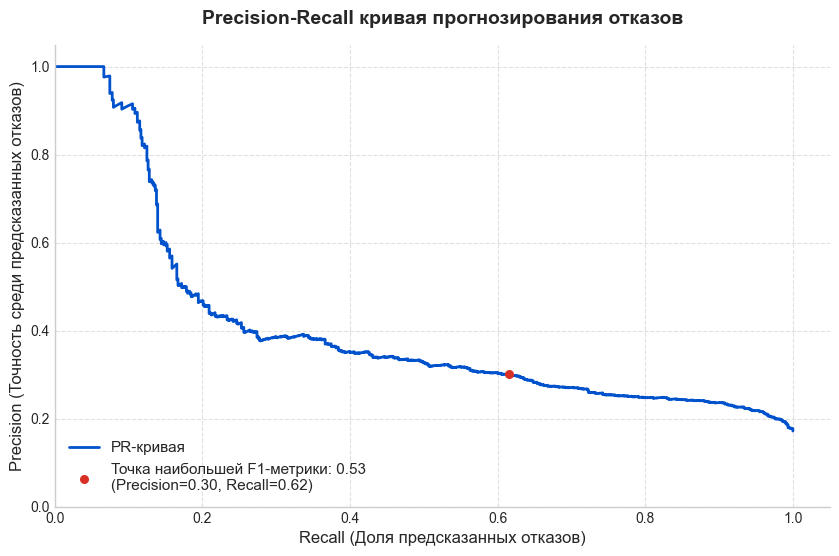

In [219]:
# Извлечение вероятностей для класса 0 
probs_class_0 = model.predict_proba(x_test)[:, 0]

# Инверсия целевой переменной для фокусировки метрик на отказах
y_test_inverted = (y_test == 0).astype(int)

# Расчет параметров кривой Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_test_inverted, probs_class_0)
ap_score = average_precision_score(y_test_inverted, probs_class_0)

# Поиск оптимального порога для максимизации F1-меры на классе отказов
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]

# Визуализация результатов
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, label=f'PR-кривая', color='#0052cc', linewidth=2)

plt.scatter(
    recall[optimal_idx], 
    precision[optimal_idx], 
    color='#d93025', 
    s=30,
    zorder=5, 
    label=f'Точка наибольшей F1-метрики: {optimal_threshold:.2f}\n(Precision={precision[optimal_idx]:.2f}, Recall={recall[optimal_idx]:.2f})'
)

plt.title('Precision-Recall кривая прогнозирования отказов', fontsize=14, pad=15)
plt.xlabel('Recall (Доля предсказанных отказов)', fontsize=12)
plt.ylabel('Precision (Точность среди предсказанных отказов)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='lower left', fontsize=11)
plt.xlim([0.0, 1.05])
plt.ylim([0.0, 1.05])

# Удаление лишних рамок графика для чистоты визуализации
import matplotlib.ticker as ticker
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.show()


### 5 Финансовый анализ потерь
Выполнил: Алина Мясникова

Всего заказов: 17,966 шт.
Отмененных заказов: 3,084 шт.
Средний процент выкупа: 82.8%
Недополученная выручка: 35,952,479 Руб
Затраты на логистику: 7,756,843 Руб

 Топ-10 по убыткам: Менеджеры (ID) (От 10 заказов)


,Всего_заказов,Кол_во_отказов,Процент_выкупа_%,Прямой_убыток_логистики_Руб,Упущенная_выручка_Руб
contact_responsible_user_id,,,,,
1,3911,569,85.5,"1,441,207","5,696,800"
29,2505,450,82.0,"1,120,753","5,166,569"
5,1782,390,78.1,"952,804","4,928,569"
0,2670,330,87.6,"858,019","3,774,894"
2,1519,286,81.2,"704,415","3,133,843"
6,888,175,80.3,"449,845","2,150,214"
8,764,150,80.4,"367,889","1,822,198"
4,671,137,79.6,"355,058","1,828,145"
3,697,78,88.8,"211,502","673,990"


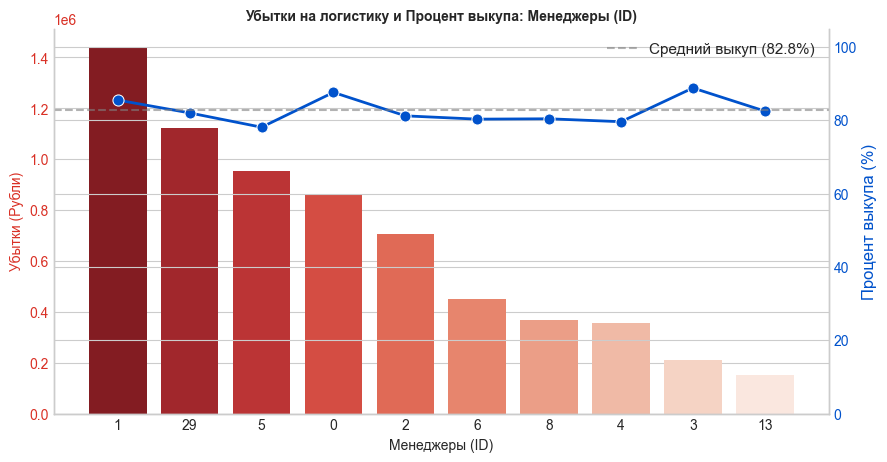



 Топ-10 по убыткам: Города и Регионы (От 10 заказов)


,Всего_заказов,Кол_во_отказов,Процент_выкупа_%,Прямой_убыток_логистики_Руб,Упущенная_выручка_Руб
contact_Город,,,,,
3501,2125,300,85.9,"829,153","3,555,792"
4320,701,94,86.6,"259,316","1,021,088"
2563,218,38,82.6,"106,362","562,521"
3772,239,37,84.5,"101,728","422,248"
4865,121,30,75.2,"81,230","362,618"
3085,176,28,84.1,"75,726","360,111"
4915,152,27,82.2,"75,573","318,442"
3984,149,26,82.6,"70,160","275,816"
2319,125,24,80.8,"67,176","232,763"


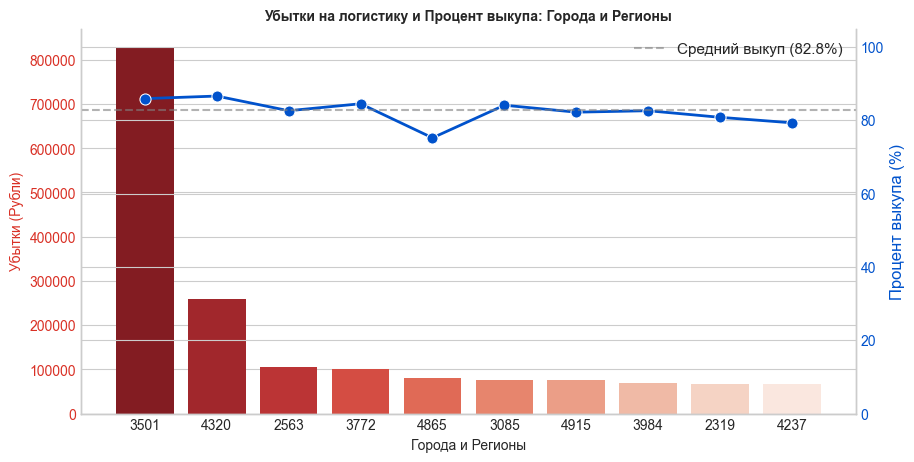



 Топ-10 по убыткам: Службы доставки (От 10 заказов)


,Всего_заказов,Кол_во_отказов,Процент_выкупа_%,Прямой_убыток_логистики_Руб,Упущенная_выручка_Руб
lead_Служба доставки,,,,,
3,12588,1925,84.7,"5,388,075","21,852,112"
2,2416,456,81.1,"1,276,344","6,118,918"
1,2922,687,76.5,"1,047,875","7,902,308"
5,15,13,13.3,"36,387","53,150"
4,23,2,91.3,"5,598","19,441"


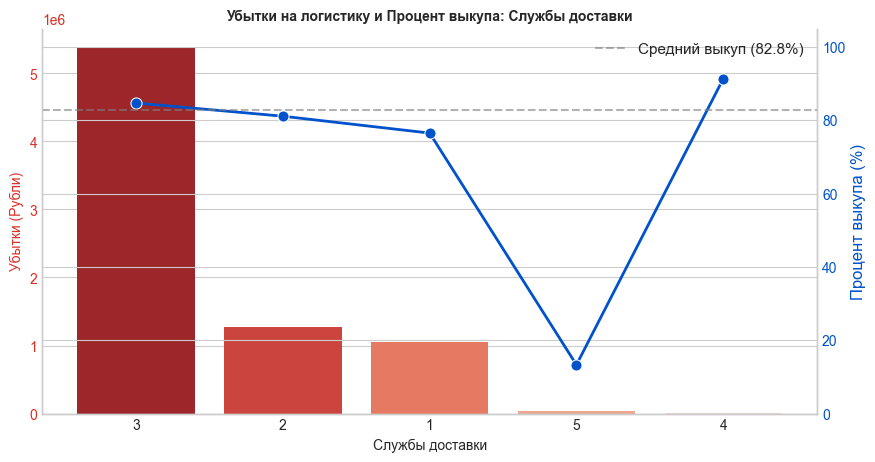



 Топ-10 по убыткам: Тарифы доставки (От 10 заказов)


,Всего_заказов,Кол_во_отказов,Процент_выкупа_%,Прямой_убыток_логистики_Руб,Упущенная_выручка_Руб
lead_Тариф Доставки,,,,,
2,12611,2060,83.7,"5,473,779","23,579,676"
0,2303,448,80.5,"1,242,914","6,113,994"
3,1763,406,77.0,"589,984","4,944,253"
9,1081,121,88.8,"332,590","717,189"
6,121,27,77.7,"75,573","324,807"
5,26,8,69.2,"22,392","108,003"
4,47,12,74.5,"17,279","149,017"


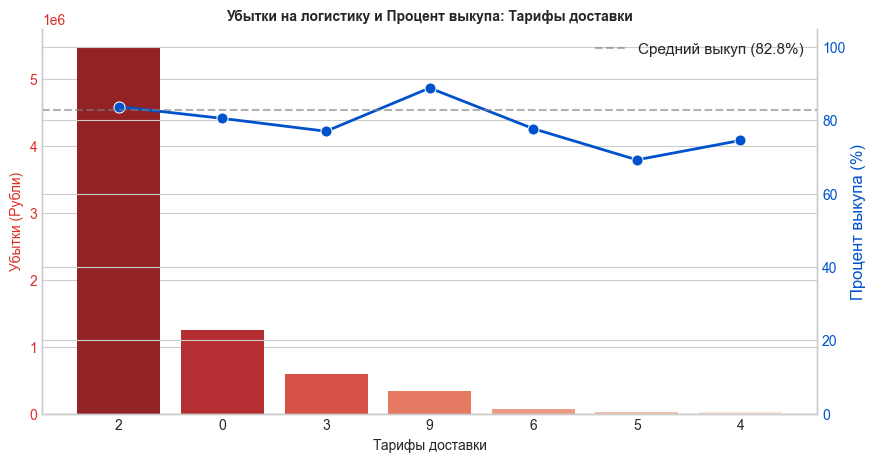

In [220]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Функция для анализа категорий по убыткам и проценту выкупа
def analyze_losses_relative(df, column, title, top_n=10, min_orders=10):
    if column not in df.columns:
        return
    
    df[column] = df[column].fillna('unknown').astype(str)
    
    # Группируем данные по всем заказам (выкупы и отказы)
    grouped = df.groupby(column).agg(
        Всего_заказов=('buyout_flag', 'count'),
        Кол_во_отказов=('buyout_flag', lambda x: (x == 0).sum()),
        Выкупов=('buyout_flag', lambda x: (x == 1).sum()),
        Прямой_убыток_логистики_Руб=('direct_loss', 'sum'),
        Упущенная_выручка_Руб=('lost_revenue', 'sum')
    )
    
    # Отсекаем категории со слишком малым числом заказов (убираем случайные выбросы)
    grouped = grouped[grouped['Всего_заказов'] >= min_orders].copy()
    
    # Считаем процент выкупа
    grouped['Процент_выкупа_%'] = (grouped['Выкупов'] / grouped['Всего_заказов'] * 100).round(1)
    
    # Сортируем по убыткам
    grouped = grouped.sort_values(by='Прямой_убыток_логистики_Руб', ascending=False).head(top_n)
    
    print(f" Топ-{top_n} по убыткам: {title} (От {min_orders} заказов)")
    
    # Форматируем для красивого вывода
    formatted = grouped.copy()
    formatted['Прямой_убыток_логистики_Руб'] = formatted['Прямой_убыток_логистики_Руб'].apply(lambda x: f"{x:,.0f}")
    formatted['Упущенная_выручка_Руб'] = formatted['Упущенная_выручка_Руб'].apply(lambda x: f"{x:,.0f}")
    
    cols_order = ['Всего_заказов', 'Кол_во_отказов', 'Процент_выкупа_%', 'Прямой_убыток_логистики_Руб', 'Упущенная_выручка_Руб']
    display(formatted[cols_order])
    
    # Визуализация (Двойная ось)
    fig, ax1 = plt.subplots(figsize=(10, 5))
    
    # График 1: Абсолютные убытки (Bars)
    sns.barplot(
        x=grouped.index, 
        y='Прямой_убыток_логистики_Руб', 
        data=grouped, 
        palette='Reds_r',
        ax=ax1
    )
    ax1.set_ylabel('Убытки (Рубли)', color='#d93025', fontsize=10)
    ax1.tick_params(axis='y', labelcolor='#d93025')
    ax1.set_xlabel(title, fontsize=10)
    
    # График 2: Процент выкупа (Line)
    ax2 = ax1.twinx()
    sns.lineplot(
        x=grouped.index, 
        y='Процент_выкупа_%', 
        data=grouped, 
        color='#0052cc', 
        marker='o',
        linewidth=2,
        markersize=8,
        ax=ax2
    )
    ax2.set_ylabel('Процент выкупа (%)', color='#0052cc', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='#0052cc')
    ax2.set_ylim(0, 105) 
    
    # Средний выкуп по компании
    ax2.axhline(overall_buyout_rate, color='gray', linestyle='--', alpha=0.6, label=f'Средний выкуп ({overall_buyout_rate:.1f}%)')
    ax2.legend(loc='upper right', fontsize=11)
    
    plt.title(f'Убытки на логистику и Процент выкупа: {title}', fontsize=10)
    
    # Убираем верхние рамки
    ax1.spines['top'].set_visible(False)
    ax2.spines['top'].set_visible(False)
    
    plt.show()
    print("\n")


# 1. Загрузка оригинального датасета
df_fin = pd.read_csv('output_2.csv', low_memory=False)

# Оставляем только заказы с известным исходом (без 2, только 0 и 1)
df_fin = df_fin[df_fin['buyout_flag'].isin([0, 1])].copy()

# 2. Очистка финансовых колонок
for col in ['lead_price', 'lead_Стоимость доставки']:
    df_fin[col] = pd.to_numeric(df_fin[col], errors='coerce').fillna(0)

# 3. Расчет общих показателей
# Считаем убытки (для отказов берем стоимость доставки, для выкупов убыток = 0)
df_fin['direct_loss'] = np.where(df_fin['buyout_flag'] == 0, df_fin['lead_Стоимость доставки'], 0)
df_fin['lost_revenue'] = np.where(df_fin['buyout_flag'] == 0, df_fin['lead_price'], 0)

total_orders = len(df_fin)
total_refusals = len(df_fin[df_fin['buyout_flag'] == 0])
overall_buyout_rate = (total_orders - total_refusals) / total_orders * 100

total_lost_revenue = df_fin['lost_revenue'].sum()
total_direct_loss = df_fin['direct_loss'].sum()

print(f"Всего заказов: {total_orders:,.0f} шт.")
print(f"Отмененных заказов: {total_refusals:,.0f} шт.")
print(f"Средний процент выкупа: {overall_buyout_rate:.1f}%")
print(f"Недополученная выручка: {total_lost_revenue:,.0f} Руб")
print(f"Затраты на логистику: {total_direct_loss:,.0f} Руб\n")


# 4. Анализ категорий по убыткам
analyze_losses_relative(df_fin, 'contact_responsible_user_id', 'Менеджеры (ID)')
analyze_losses_relative(df_fin, 'contact_Город', 'Города и Регионы')
analyze_losses_relative(df_fin, 'lead_Служба доставки', 'Службы доставки')
analyze_losses_relative(df_fin, 'lead_Тариф Доставки', 'Тарифы доставки')

### 6. Формирование отчета и визуализаций


В ходе исследования проведен полный цикл анализа данных о заказах. Основная проблема — высокие издержки на логистику из-за отказов клиентов (наложенный платеж используется в >95% случаев).

**Ключевые показатели (KPI):**
* **Общий объем выборки:** 17 966 заказов.
* **Базовый процент выкупа:** 82,8%.
* **Прямые логистические издержки по отказам:** 7 756 843 руб.
* **Упущенная выручка:** 35 952 479 руб.

**Результаты моделирования:**
Разработанная модель на базе CatBoost позволяет идентифицировать **65% потенциальных отказов**. При наличии системы скоринга компания могла предотвратить до **5,04 млн руб.** прямых убытков. 

Анализ показал, что 98% всех потерь генерируется при выборе наложенного платежа. При этом относительный анализ выявил, что менеджеры с самыми высокими суммами убытков (ID 1, ID 29) работают эффективнее среднего уровня, а основная проблема кроется в «остывании» клиентов.


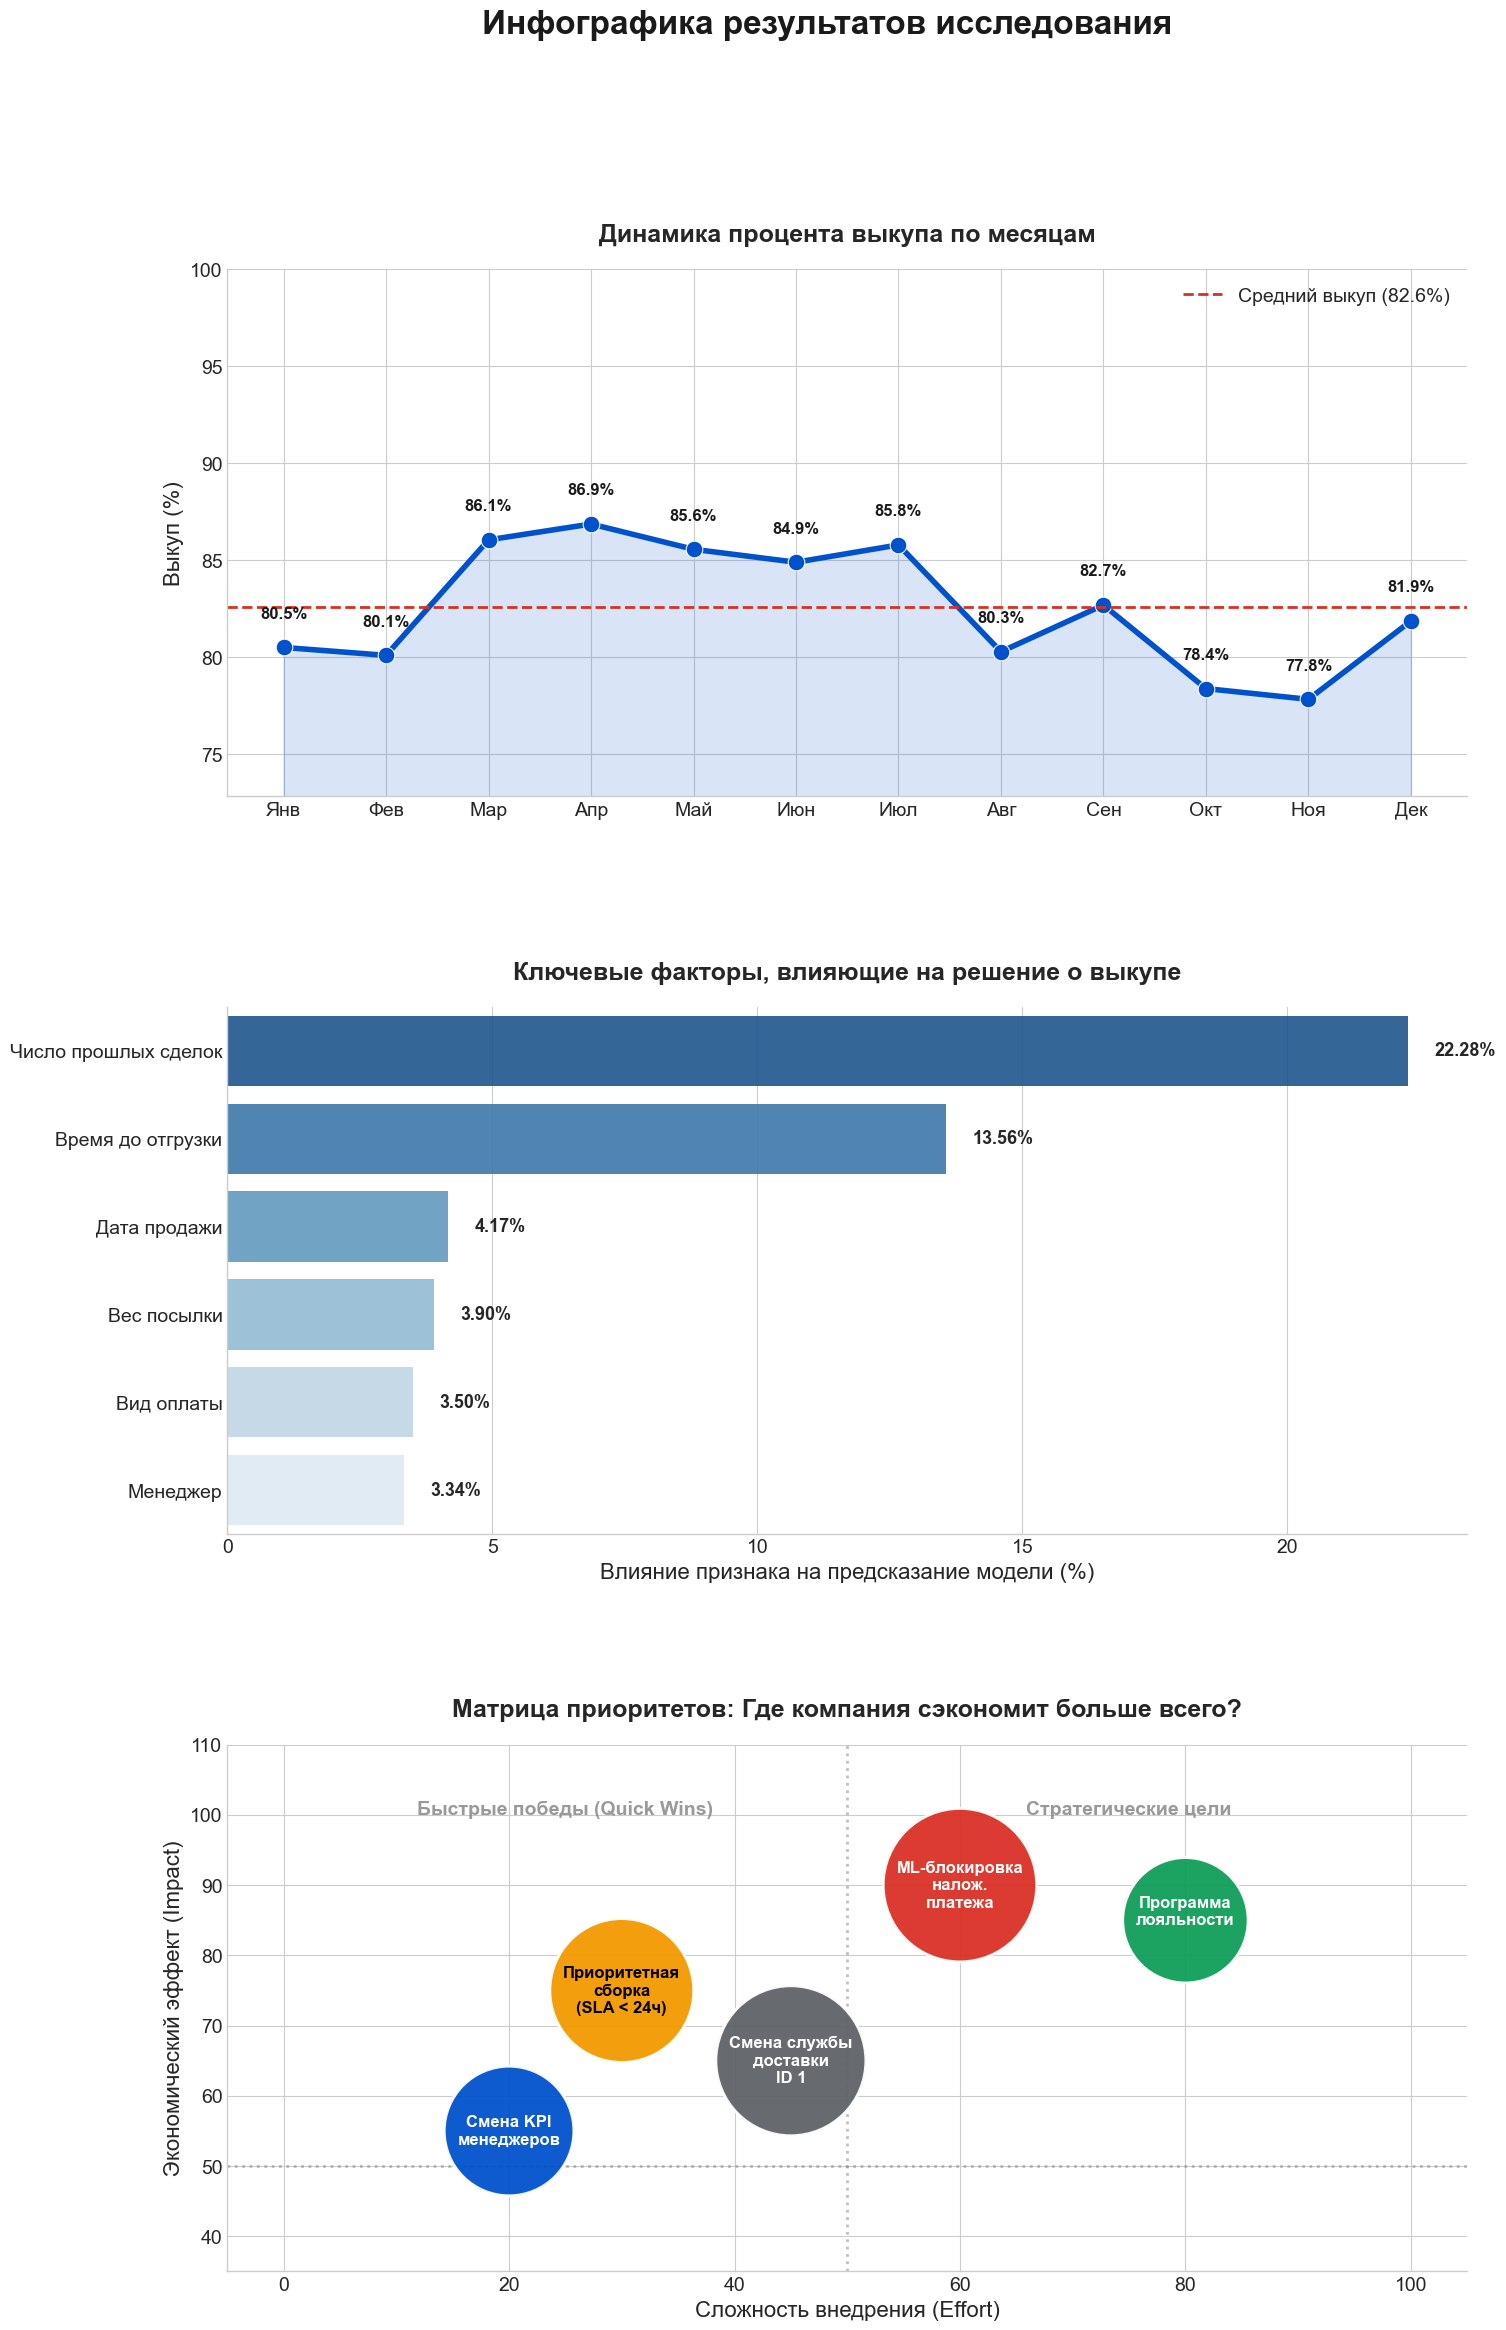

In [234]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

if 'sale_ts' in df_fin.columns:
    dt_sale = pd.to_datetime(df_fin['sale_ts'], unit='s', errors='coerce')
    df_fin['sale_month_num'] = dt_sale.dt.month

# Добавляем цифры в начало, чтобы график отсортировался хронологически, а не по алфавиту
MONTHS_RU = {
    1: '01 Янв', 2: '02 Фев', 3: '03 Мар', 4: '04 Апр',
    5: '05 Май', 6: '06 Июн', 7: '07 Июл', 8: '08 Авг',
    9: '09 Сен', 10: '10 Окт', 11: '11 Ноя', 12: '12 Дек'
}

# Если sale_month_name_ru еще не создан или нужно обновить
if 'sale_month_name_ru' not in df_fin.columns or df_fin['sale_month_name_ru'].iloc[0] not in MONTHS_RU.values():
    df_fin['sale_month_name_ru'] = df_fin['sale_month_num'].map(MONTHS_RU)

# Настройка стиля
plt.style.use('seaborn-v0_8-whitegrid')
fig = plt.figure(figsize=(16, 26))
fig.suptitle('Инфографика результатов исследования', 
             fontsize=24, fontweight='bold', y=0.98, color='#1a1a1a')

gs = fig.add_gridspec(3, 1, hspace=0.4)

# 1. Динамика выкупа 
ax1 = fig.add_subplot(gs[0, 0])

# Группируем данные по месяцам из вашего датасета
monthly_data = df_fin.groupby('sale_month_name_ru')['buyout_flag'].mean().sort_index() * 100

# Убираем цифры из названий месяцев для красоты
months_labels = [str(m)[3:] for m in monthly_data.index.tolist()]
buyout_values = monthly_data.values

sns.lineplot(x=months_labels, y=buyout_values, ax=ax1, color='#0052cc', marker='o', linewidth=4, markersize=12)
ax1.fill_between(months_labels, buyout_values, alpha=0.15, color='#0052cc')

# Средний уровень
mean_val = buyout_values.mean()
ax1.axhline(mean_val, color='#d93025', linestyle='--', linewidth=2, label=f'Средний выкуп ({mean_val:.1f}%)')

ax1.set_title('Динамика процента выкупа по месяцам', fontsize=18, fontweight='bold', pad=20)

#  Подписи оси и размер шрифта значений на осях X и Y
ax1.set_ylabel('Выкуп (%)', fontsize=16) 
ax1.tick_params(axis='both', labelsize=14) 

ax1.set_ylim(min(buyout_values) - 5, 100)
ax1.legend(loc='upper right', fontsize=14)

for i, val in enumerate(buyout_values):
    ax1.text(i, val + 1.5, f'{val:.1f}%', ha='center', fontweight='bold', color='#1a1a1a', fontsize=12)

# 2. Значимость факторов (Важность признаков модели классификации)

ax2 = fig.add_subplot(gs[1, 0])

importance_data = {
    'Фактор': ['Число прошлых сделок', 'Время до отгрузки', 'Дата продажи', 'Вес посылки', 'Вид оплаты', 'Менеджер'],
    'Значимость': [22.28, 13.56, 4.17, 3.90, 3.50, 3.34]
}
df_imp = pd.DataFrame(importance_data)

sns.barplot(x='Значимость', y='Фактор', data=df_imp, palette='Blues_r', ax=ax2, alpha=0.9)

ax2.set_title('Ключевые факторы, влияющие на решение о выкупе', fontsize=18, fontweight='bold', pad=20)

# УВЕЛИЧЕНО: Подпись оси X и размер шрифта значений факторов
ax2.set_xlabel('Влияние признака на предсказание модели (%)', fontsize=16)
ax2.set_ylabel('')
ax2.tick_params(axis='both', labelsize=14)

for i, v in enumerate(df_imp['Значимость']):
    ax2.text(v + 0.5, i, f'{v:.2f}%', va='center', fontweight='bold', fontsize=13)

# График 3. Приоритизация гипотез
ax3 = fig.add_subplot(gs[2, 0])

# Делаем текст компактным (квадратным), чтобы круги получались аккуратными
hypotheses = [
    {'name': 'ML-блокировка\nналож.\nплатежа', 'effect': 90, 'effort': 60, 'color': '#d93025', 'text_color': 'white'},
    {'name': 'Приоритетная\nсборка\n(SLA < 24ч)', 'effect': 75, 'effort': 30, 'color': '#f29900', 'text_color': 'black'},
    {'name': 'Программа\nлояльности\n', 'effect': 85, 'effort': 80, 'color': '#0f9d58', 'text_color': 'white'},
    {'name': 'Смена KPI\nменеджеров', 'effect': 55, 'effort': 20, 'color': '#0052cc', 'text_color': 'white'},
    {'name': 'Смена службы\nдоставки\nID 1', 'effect': 65, 'effort': 45, 'color': '#5f6368', 'text_color': 'white'}
]
df_h = pd.DataFrame(hypotheses)

ax3.axvline(50, color='gray', linestyle=':', alpha=0.5, linewidth=2)
ax3.axhline(50, color='gray', linestyle=':', alpha=0.5, linewidth=2)

ax3.text(25, 100, 'Быстрые победы (Quick Wins)', ha='center', fontsize=14, color='gray', fontweight='bold', alpha=0.8)
ax3.text(75, 100, 'Стратегические цели', ha='center', fontsize=14, color='gray', fontweight='bold', alpha=0.8)

# Рисуем круги динамически вокруг текста
for i, row in df_h.iterrows():
    ax3.text(row['effort'], row['effect'], row['name'], 
             ha='center', va='center', fontsize=12, fontweight='bold', color=row['text_color'],
             bbox=dict(boxstyle="circle,pad=0.8", facecolor=row['color'], edgecolor='white', linewidth=2, alpha=0.95))

ax3.set_title('Матрица приоритетов: Где компания сэкономит больше всего?', fontsize=18, fontweight='bold', pad=20)

# Подписи осей X и Y, а также значения шкалы
ax3.set_xlabel('Сложность внедрения (Effort)', fontsize=16)
ax3.set_ylabel('Экономический эффект (Impact)', fontsize=16)
ax3.tick_params(axis='both', labelsize=14)

# Делаем отступы на осях, чтобы динамические круги не обрезались
ax3.set_xlim(-5, 105)
ax3.set_ylim(35, 110)

# Финальная очистка и вывод
for ax in [ax1, ax2, ax3]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.show()

### 7. Генерация гипотез для бизнеса

**Гипотеза 1: Умная блокировка наложенного платежа**
* **Суть:** Поскольку 98% убытков генерирует оплата при получении, предлагается внедрить ML-скоринг в реальном времени.
* **Действие:** Если модель оценивает вероятность отказа выше 70%, опция «Оплата при получении» скрывается, предлагается онлайн-оплата со скидкой.
* **Ожидаемый эффект:** Снижение логистических убытков на 30-40%.

**Гипотеза 2: Скорость сборки и «выгорание» клиента**
* **Суть:** Время передачи в доставку (days_sale_to_handed) — второй по важности признак модели (13,56%).
* **Действие:** Заказы с наложенным платежом должны комплектоваться в приоритетном порядке в течение 12-24 часов.
* **Ожидаемый эффект:** Рост выкупа за счет сокращения времени на изменение решения.

**Гипотеза 3: Ревизия логистических партнеров**
* **Суть:** Служба доставки ID 1 показывает выкуп 76,5%, что на 6,3% ниже среднего.
* **Действие:** Перераспределить объемы в пользу Службы ID 3 (выкуп 84,7%) или провести аудит качества.
* **Ожидаемый эффект:** Снижение издержек в канале.

**Гипотеза 4: Система мотивации персонала**
* **Суть:** Менеджер ID 5 имеет выкуп 78,1% при среднем 85,5% у лидеров.
* **Действие:** Смена KPI. Например привязать бонусы менеджеров не к количеству подтвержденных лидов, а к проценту фактически выкупленных заказов.
*  **Ожидаемый эффект:** Уменьшение числа возвратов.


**Гипотеза 5: Программа лояльности**
* **Суть:** История сделок (contact_Число сделок) — самый мощный фактор выкупа (23%).
* **Действие:** Стимулировать повторные продажи через вложение купонов в первые заказы.
*  **Ожидаемый эффект:** Увеличение числа выкупленных заказов.